# PRACTICAL SESSION 04

## MODULES IMPORT

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from astropy import constants as const
from astropy import units as u

from scipy.stats import norm
from scipy.stats import uniform

# 1 - INPUT GENERATION:

## CHOSING UNITS

In [2]:
# Chosen units (same name as in astropy https://docs.astropy.org/en/stable/units/#module-astropy.units.astrophys)
my_u = ["pc","year","M_sun"]

# Physical constants converted to chosen units
G = const.G.to(my_u[0] + "^3/(" + my_u[1] + "^2" + my_u[2]+")").value
c = const.c.to(my_u[0] + "/" + my_u[1]).value
print("G =",G,"c =",c)

# Conversion constants between physical and internal units
R0 = 1.
M0 = 2 # R0**3 / (G * T0**2)
T0 = np.sqrt(R0**3 / (G * M0)) # 1000

G = 4.498502151469552e-15 c = 0.30660139378555057


In [3]:
# SETTING SOME CONSTANTS AND SAMPLING THE DIRECTIONS

N = 5000

# System properties (defining normalization factors)
M = 10000 # total mass
a = 10 # scale radius
U = G * M / a # normalization of the potential

# Masses - considering N p.cles of equal mass
m = M / N * np.ones(N)

# Angular positions
phi = 2 * np.pi * uniform.rvs(size=N)
the = np.arccos(1 - 2 * uniform.rvs(size=N))

# Velocity directions
csi = 2 * np.pi * uniform.rvs(size=N)
zet = np.arccos(1 - 2 * uniform.rvs(size=N))

## POSITION SAMPLING

In [4]:
# Gravitational potential normalized by -U
def psi(r):
  return 1 / np.sqrt(1 + r**2)
# NOTE: the density is proportional to psi^5


# Radius as a function of mass (useful to generate r with the inverse function method)
def radius(M):
  return 1 / np.sqrt(1 / M**(2/3) - 1)

In [5]:
rho = radius(uniform.rvs(size=N))

x = a * rho * np.sin(the) * np.cos(phi)
y = a * rho * np.sin(the) * np.sin(phi)
z = a * rho * np.cos(the)

## VELOCITY SAMPLING

In [6]:
# Absolute value of the energy normalized by U
def epsilon(r, v):
    return psi(r) - v**2 / 2

def f(r, v):
    E = epsilon(r, v)
    mask = (E > 0) & (v > 0)
    out = np.zeros(v.shape)
    out[mask] = v[mask]**2 * E[mask]**(7/2)
    return out

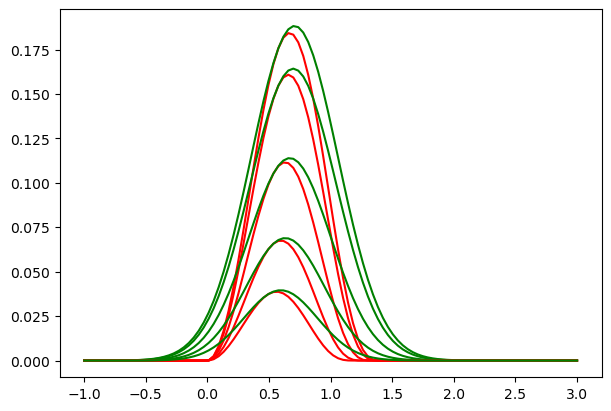

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), layout='constrained')

r = np.linspace(0, 1, 5)

for i in r:
    v_max = np.sqrt(2 * psi(i))
    x = np.linspace(-1, 3, 100)

    gaus = norm(v_max / 2, v_max / 4)
    k = np.max(f(i, x) / gaus.pdf(x))
    ax.plot(x, f(i, x), color='r')
    ax.plot(x, k * gaus.pdf(x), color='g')

In [7]:
# Very nice implementation (it seems) (retcon: maybe not)

n = 500
vs, r = np.meshgrid(np.linspace(0, 5, n), rho)

k = np.max(f(r, vs) / norm.pdf(vs), axis=1)
__, k = np.meshgrid(np.linspace(0, 5, n), k)

vm = np.sqrt(2 * psi(r))
gaus = norm(vm / 2, vm / 4)

vs = gaus.rvs()
us = uniform.rvs(size=vs.shape)

mask = f(r, vs) / (k * gaus.pdf(vs)) <= us
vs[mask] = -1

#for i in range(N):
    #print(r[i][0], '\t', vs[i][vs[i] >= 0].shape, '\t', vs[i][vs[i] == -1].shape, '\n')

In [8]:
vel = np.zeros(N)
for i in range(N):
    vel[i] = vs[i][vs[i] != -1][0]

vx = np.sqrt(U) * vel * np.sin(zet) * np.cos(csi)
vy = np.sqrt(U) * vel * np.sin(zet) * np.sin(csi)
vz = np.sqrt(U) * vel * np.cos(zet)

## PRINT FILE

In [9]:
file_in = 'IF05.txt'

In [15]:
# INTEGRATION PARAMETERS (for treecode)
# NOTE: parameters must be converted in internal units

eps, alpha = 1, .05

r_ext = a #* rho.max()
M_ext = M * r_ext**3 / (r_ext**2 + a**2)**(3/2)
T_ext = 2 * np.pi * r_ext**(3/2) / np.sqrt(G * M_ext)

M_eps = M * eps**3 / (eps**2 + a**2)**(3/2)
T_eps = 2 * np.pi * eps**(3/2) / np.sqrt(G * M_eps)

t_eps = eps**(3/2) / np.sqrt(G * m[0])

print('M(a) =', round(M_ext / M0, 2), '\tT_orb =', round(T_ext / T0, 2))
print('M(eps) =', round(M_eps / M0, 2), '\tT_eps =', round(T_eps / T0, 2))
print('m_p =', round(m[0] / M0, 2), '\tt_eps =', round(t_eps / T0, 2))
print('Conversion constants: R0 =', R0, 'T0 =', T0, 'M0 =', M0)

M(a) = 1767.77 	T_orb = 4.73
M(eps) = 4.93 	T_eps = 2.83
m_p = 0.0 	t_eps = 14909601.35
Conversion constants: R0 = 1.0 T0 = 10542680.273053497 M0 = 2


In [10]:
# FOR TREECODE

m = m / M0

x = x / R0
y = y / R0
z = z / R0

vx = vx / R0 * T0
vy = vy / R0 * T0
vz = vz / R0 * T0

n_dim = 3
time_in = 0 # initial time

out_r = np.column_stack((x, y, z))
out_v = np.column_stack((vx, vy, vz))
with open(file_in, 'w') as file:
    file.write(f'{N}\n')
    file.write(f'{n_dim}\n')
    file.write(f'{time_in}\n')
    for i in m:
        file.write(f'{i}\n')
    np.savetxt(file, out_r)
    np.savetxt(file, out_v)

# 2 - ANALYSIS

In [11]:
# Reading file

file_out = 'OF05-2.txt'

n = 3 * N + 3 # 'block' length
m = 3     # number of rows to skip (i.e. lines containing n. bodies and time)

time_rows = []
m_rows, r_rows, v_rows = [], [], []
with open(file_out, "r") as file:
    lines = file.readlines()
    for i in range(0, len(lines), n):  # move through rows every n rows
        time_rows.extend(lines[i+2:i+m])
        m_rows.extend(lines[i+m:i+N+3])
        r_rows.extend(lines[i+N+3:i+2*N+3])
        v_rows.extend(lines[i+2*N+3:i+n])

time = np.loadtxt(time_rows)

In [12]:
# Fetching data

m = np.loadtxt(m_rows) # masses

r = np.loadtxt(r_rows) # positions
d = np.linalg.norm(r, axis=1) # distance from center

v = np.loadtxt(v_rows) # velocities
vm = np.linalg.norm(v, axis=1)

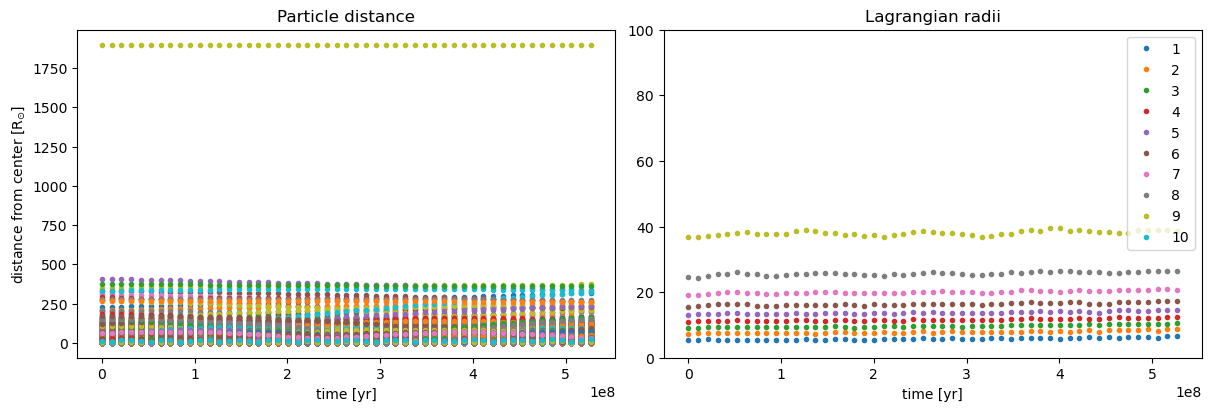

In [15]:
# Plotting distance vs time in the CF

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

d_mtx = d.reshape((time.size, N))
d_sort = np.sort(d_mtx, axis=1)

# Distance from the CF center of each p.cle
for i in range(N):
    #ax.plot(time, d[i::N], '.')
    ax.plot(time * T0, d_mtx[:, i], '.')

ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [R$_{\odot}$]')

# Lagrangian radii in the CF
for i in range(10):
    bx.plot(time * T0, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()

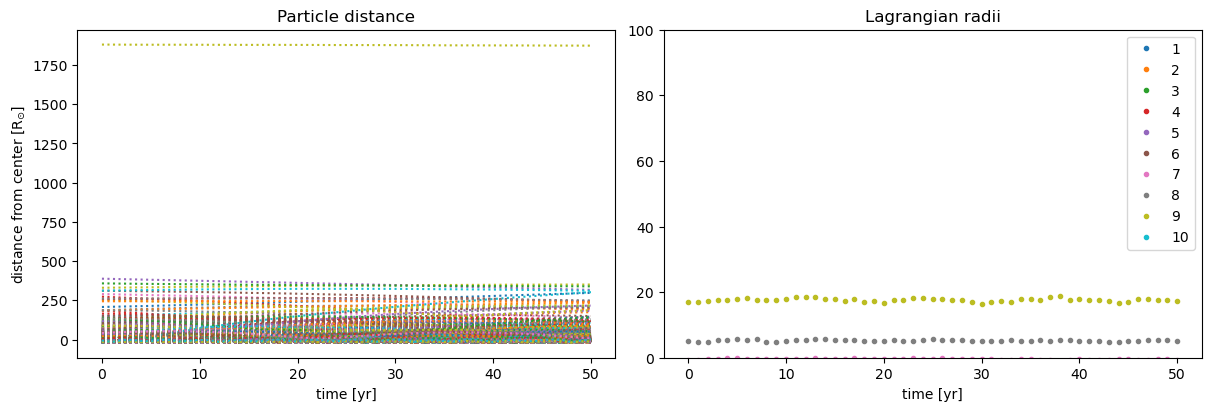

In [17]:
# Plotting distance vs time in the system center (i.e. the CM) !! to be updated !!

fig, (ax, bx) = plt.subplots(1, 2, figsize=(12, 4), layout='constrained')

_, r_cm = np.meshgrid(np.zeros(N), d_mtx.mean(axis=1))

d_cm = d_mtx - r_cm
d_sort = np.sort(d_cm, axis=1)

# Distance of each p.cle from the CM
for i in range(N):
    ax.plot(time, d_cm[:, i], ':')
    
ax.set_title('Particle distance')
ax.set_xlabel('time [yr]')
ax.set_ylabel('distance from center [R$_{\odot}$]')

# Lagrangian radii
for i in range(10):
    bx.plot(time, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

bx.set_ylim(0, 100)

bx.set_title('Lagrangian radii')
bx.set_xlabel('time [yr]')
bx.legend()

plt.show()

# TEST

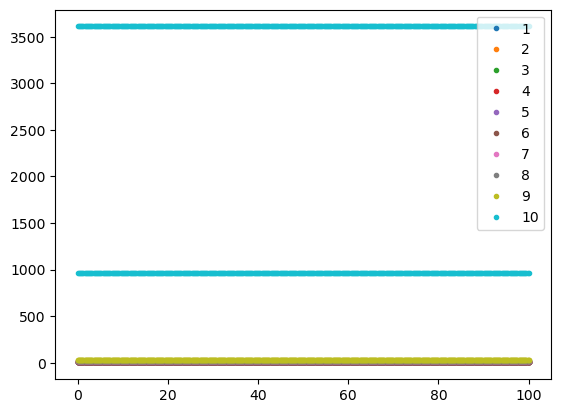

In [6]:
d_mtx = d.reshape((time.size, N))

d_sort = np.sort(d_mtx, axis=1)
for i in range(10):
    plt.plot(time, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

#plt.ylim(0, 100)
plt.legend()
plt.show()

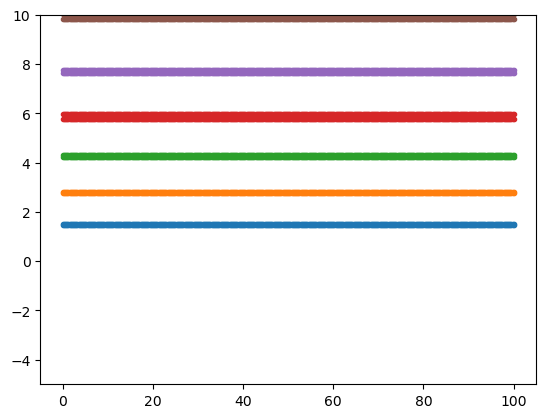

In [59]:
# Long but working!!!

x, y, z = r[:, 0].reshape(time.size, N), r[:, 1].reshape(time.size, N), r[:, 2].reshape(time.size, N)

_, x_cm = np.meshgrid(np.zeros(N), x.mean(axis=1))
_, y_cm = np.meshgrid(np.zeros(N), y.mean(axis=1))
_, z_cm = np.meshgrid(np.zeros(N), z.mean(axis=1))

x_CM = x - x_cm
y_CM = x - y_cm
z_CM = x - z_cm

d_CM = np.sqrt(x_CM**2 + y_CM**2 + z_CM**2)
d_sort = np.sort(d_CM, axis=1)

for i in range(10):
    plt.plot(time, d_sort[:, int((i+1) * N / 10) - 1], '.', label=i+1)

plt.ylim(-5, 10)
plt.show()

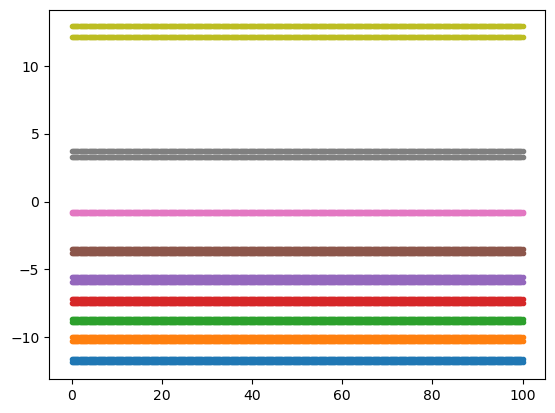

In [32]:
_, r_cm = np.meshgrid(np.zeros(N), d_mtx.mean(axis=1))
#r_cm = d_mtx.mean(axis=1)

d_cm = d_mtx - r_cm
d_sort = np.sort(d_cm, axis=1)

plt.plot(time, d_sort[:, int(N/10):-1:int(N/10)], '.')
plt.show()